## Predicción de supervivencia de pasajeros del Titanic

### Introducción

En este proyecto se trabajará con un dataset de pasajeros del Titanic con el objetivo de preparar los datos para desarrollar posteriormente un modelo de Machine Learning capaz de predecir la supervivencia de los pasajeros.

En esta primera etapa se realizará la selección y exploración del dataset, el análisis exploratorio de los datos (EDA), la identificación y tratamiento de valores faltantes y duplicados, el análisis de outliers y correlaciones, la transformación de variables y la selección de las variables que serán utilizadas en el modelado.

Finalmente, se dividirán los datos en conjuntos de entrenamiento y prueba, dejando el dataset preparado para la etapa posterior de entrenamiento y evaluación de modelos de clasificación.

## 1. Importación de librerías

Se importan las librerías necesarias para realizar el análisis exploratorio, la limpieza, transformación y preparación de los datos.

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [184]:
from sklearn.impute import SimpleImputer

In [185]:
from sklearn.preprocessing import OneHotEncoder

## 2. Selección y carga del dataset

Para este proyecto se seleccionó el dataset **Titanic**, disponible en Kaggle. El conjunto de datos contiene información de los pasajeros que viajaban en el Titanic, incluyendo características como clase del pasajero, sexo, edad, cantidad de familiares a bordo y tarifa abonada.

La variable objetivo será `Survived`, que indica si el pasajero sobrevivió al naufragio.

Se eligió este dataset porque constituye un problema de clasificación binaria adecuado para aplicar los conocimientos de Machine Learning trabajados durante el curso. Además, presenta variables numéricas y categóricas, valores faltantes y diferentes características que permiten realizar un proceso completo de exploración y preparación de datos.

In [186]:
import pandas as pd

url = "https://raw.githubusercontent.com/mfercaballeroort/proyecto-integrador-machine-learning/refs/heads/main/Titanic-Dataset.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploración inicial de los datos

En primer lugar se realizará una exploración general del dataset para conocer su tamaño, estructura, tipos de datos y principales características.

In [187]:
print("Cantidad de filas y columnas:", df.shape)

df.info()

Cantidad de filas y columnas: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [188]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [189]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Observaciones

El dataset contiene 891 registros y 12 variables. Se observan variables de diferentes tipos: numéricas, como `Age`, `Fare`, `SibSp` y `Parch`, y categóricas, como `Sex`, `Embarked` y `Cabin`.

La variable `Survived` no presenta valores faltantes y será utilizada posteriormente como variable objetivo del modelo de clasificación.

Durante esta primera exploración se identificaron valores faltantes principalmente en `Age`, `Cabin` y `Embarked`. La variable `Age` presenta 714 valores disponibles sobre 891 registros, mientras que `Cabin` solamente cuenta con 204 valores disponibles. `Embarked` presenta únicamente 2 valores faltantes.

También se observa una importante dispersión en algunas variables numéricas. Por ejemplo, `Fare` presenta valores entre 0 y 512,33, por lo que será necesario analizar posteriormente la presencia de posibles valores atípicos.

Estos resultados permiten identificar los principales aspectos que deberán ser tratados durante las etapas de limpieza y transformación de los datos.

## 4. Análisis exploratorio de datos (EDA)

### Distribución de la supervivencia

Se analiza la distribución de la variable `Survived` para conocer la proporción de pasajeros que sobrevivieron y de aquellos que no sobrevivieron.

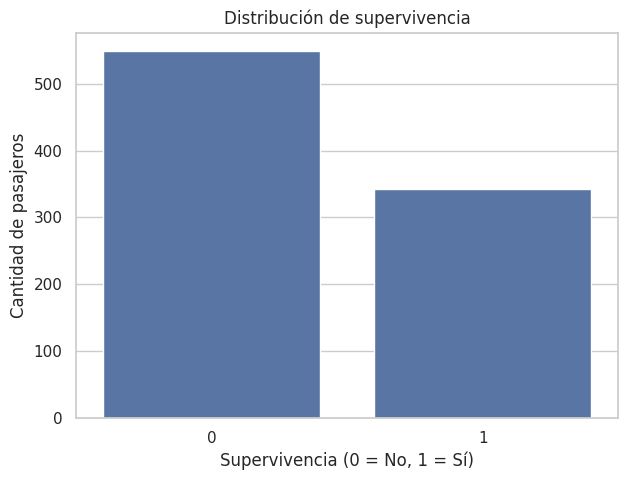

In [190]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Survived")

plt.title("Distribución de supervivencia")
plt.xlabel("Supervivencia (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de pasajeros")

plt.show()

In [191]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [192]:
df["Survived"].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


### Observación

La variable objetivo `Survived` presenta dos categorías: 0, correspondiente a los pasajeros que no sobrevivieron, y 1, correspondiente a los pasajeros que sobrevivieron.

De los 891 pasajeros del dataset, 549 no sobrevivieron (61,62%), mientras que 342 sobrevivieron (38,38%).

Se observa, por lo tanto, un predominio de la clase correspondiente a los pasajeros que no sobrevivieron. Sin embargo, la diferencia entre ambas clases no es extrema, por lo que no se considera inicialmente un problema severo de desbalance de clases.

### Distribución de pasajeros según sexo

Se analiza la distribución de los pasajeros según la variable `Sex` para conocer la composición del dataset y posteriormente evaluar su relación con la supervivencia.

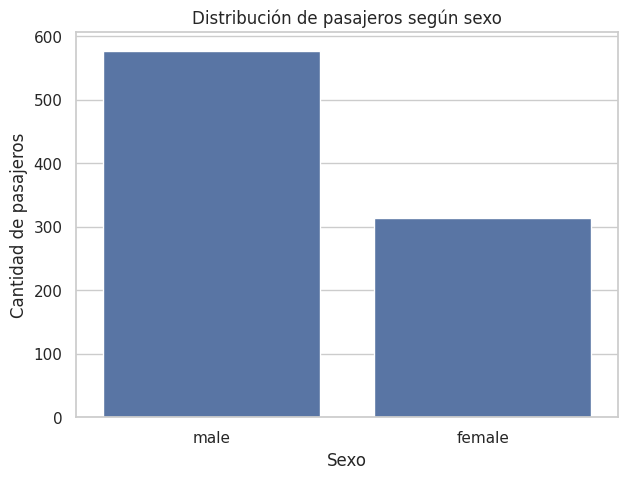

In [193]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex")

plt.title("Distribución de pasajeros según sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de pasajeros")

plt.show()

In [194]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [195]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


### Observación

El dataset contiene 577 pasajeros hombres y 314 mujeres.

Al analizar la relación entre el sexo y la supervivencia se observa una diferencia importante entre ambas categorías. El 74,20% de las mujeres sobrevivió, mientras que entre los hombres sobrevivió solamente el 18,89%.

Esta diferencia sugiere que la variable `Sex` tiene una relación relevante con la variable objetivo `Survived`, por lo que se considera una variable potencialmente importante para el modelo de clasificación.

Debido a que `Sex` es una variable categórica, posteriormente será necesario transformarla a un formato numérico antes de utilizarla en un modelo de Machine Learning.

### Distribución según clase del pasajero

Se analiza la distribución de los pasajeros según `Pclass`, variable que representa la clase socioeconómica del pasajero.

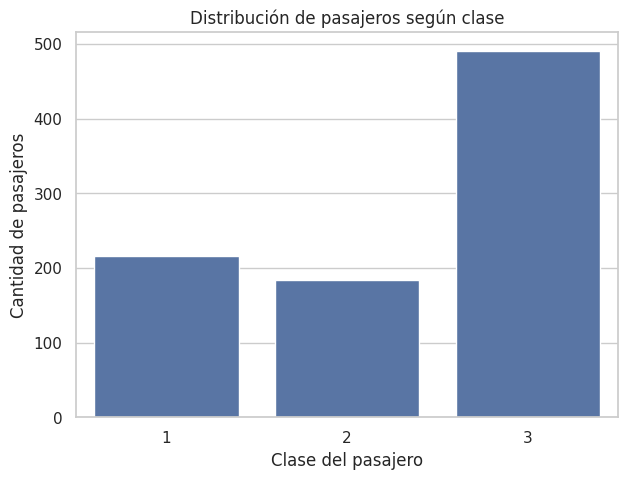

In [196]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass")

plt.title("Distribución de pasajeros según clase")
plt.xlabel("Clase del pasajero")
plt.ylabel("Cantidad de pasajeros")

plt.show()

In [197]:
df["Pclass"].value_counts().sort_index()

,count
Pclass,
1,216
2,184
3,491


In [198]:
pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


### Observación

La mayor cantidad de pasajeros pertenece a la tercera clase, con 491 pasajeros, seguida por la primera clase con 216 y la segunda clase con 184 pasajeros.

Al analizar la relación entre `Pclass` y `Survived`, se observa una diferencia importante en las tasas de supervivencia. En primera clase sobrevivió el 62,96% de los pasajeros, en segunda clase el 47,28% y en tercera clase solamente el 24,24%.

Estos resultados sugieren que la clase del pasajero presenta una relación relevante con la supervivencia. Por este motivo, `Pclass` se considera una variable potencialmente útil para el futuro modelo de clasificación.

### Distribución de la edad

Se analiza la distribución de `Age` para conocer el rango de edades de los pasajeros y detectar posibles valores extremos. También se tendrá en cuenta la presencia de valores faltantes identificada durante la exploración inicial.

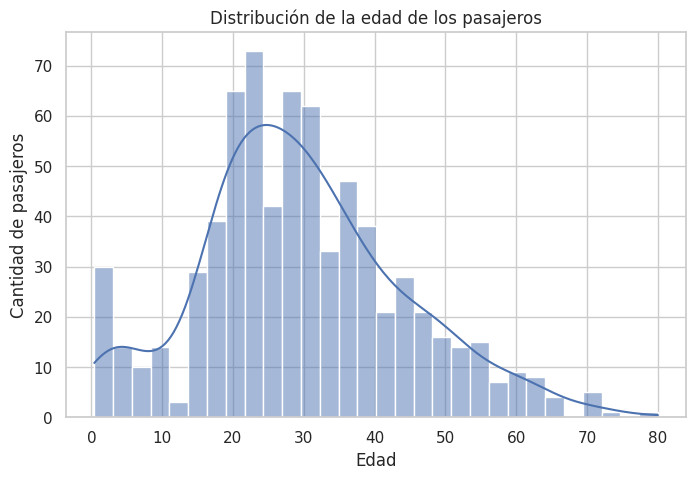

In [199]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Distribución de la edad de los pasajeros")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pasajeros")

plt.show()

In [200]:
df["Age"].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [201]:
df["Age"].isnull().sum()

np.int64(177)

### Observación

La variable `Age` presenta 714 valores disponibles y 177 valores faltantes. Entre los valores registrados, la edad media es de aproximadamente 29,70 años y la mediana es de 28 años.

Las edades observadas se encuentran entre 0,42 y 80 años, por lo que no se identifican inicialmente valores imposibles o claramente incorrectos.

Debido a la presencia de valores faltantes, será necesario realizar un tratamiento antes del modelado. Se propone utilizar la mediana para completar estos valores, ya que es una medida robusta frente a posibles valores extremos y permite conservar los registros del dataset.

### Distribución de la tarifa

Se analiza la distribución de `Fare` para identificar su comportamiento, dispersión y posibles valores atípicos.

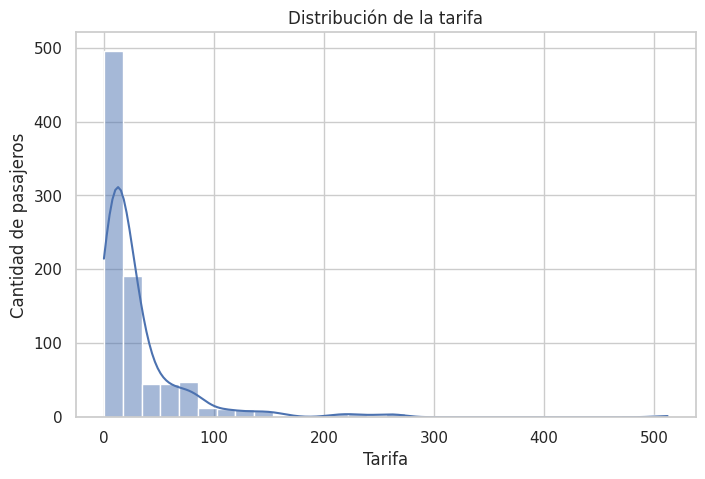

In [202]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Distribución de la tarifa")
plt.xlabel("Tarifa")
plt.ylabel("Cantidad de pasajeros")

plt.show()

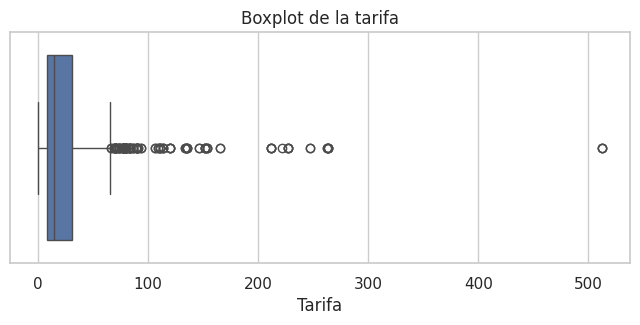

In [203]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot de la tarifa")
plt.xlabel("Tarifa")

plt.show()

In [204]:
df["Fare"].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


### Observación

El boxplot de `Fare` muestra una distribución asimétrica hacia la derecha y una cantidad considerable de valores que pueden considerarse atípicos según el criterio del rango intercuartílico (IQR).

La mayoría de las tarifas se concentra en valores relativamente bajos, mientras que se observan algunos valores considerablemente superiores, llegando hasta 512,33.

Estos valores no serán eliminados automáticamente, ya que un valor atípico desde el punto de vista estadístico no necesariamente representa un error en los datos. En este contexto, las tarifas elevadas pueden corresponder a pasajeros de determinadas clases o a características particulares de los tickets.

Por lo tanto, se conservarán inicialmente estos registros y se tendrá en cuenta la presencia de estos valores durante las etapas posteriores de transformación y modelado.

### Distribución según puerto de embarque

Se analiza la distribución de la variable `Embarked` y su relación con la supervivencia, así como la presencia de valores faltantes.

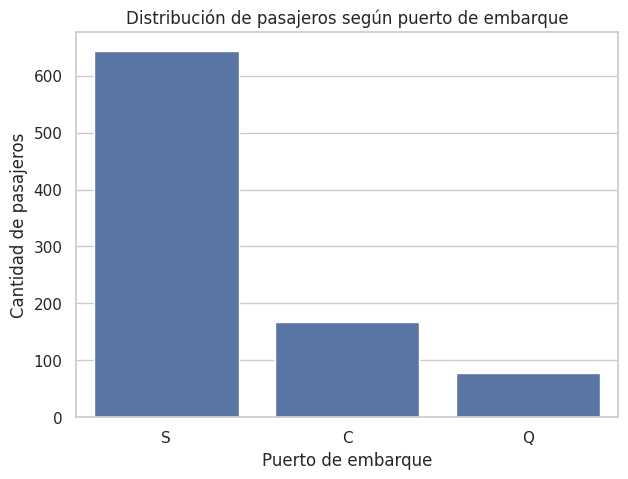

In [205]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Embarked")

plt.title("Distribución de pasajeros según puerto de embarque")
plt.xlabel("Puerto de embarque")
plt.ylabel("Cantidad de pasajeros")

plt.show()

In [206]:
df["Embarked"].value_counts(dropna=False)

,count
Embarked,
S,644
C,168
Q,77
NaN,2


In [207]:
pd.crosstab(df["Embarked"], df["Survived"], normalize="index") * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


### Observación

La mayoría de los pasajeros embarcó en Southampton (S), con 644 pasajeros, seguido por Cherbourg (C) con 168 pasajeros y Queenstown (Q) con 77 pasajeros. Se identificaron 2 valores faltantes en la variable `Embarked`.

Al analizar la relación con la supervivencia, se observa que el mayor porcentaje de supervivencia corresponde a los pasajeros que embarcaron en Cherbourg (55,36%), seguido de Queenstown (38,96%) y Southampton (33,70%).

Estos resultados sugieren que `Embarked` podría aportar información útil para el modelo de clasificación. Debido a la presencia de solamente 2 valores faltantes, posteriormente se deberá aplicar un tratamiento adecuado para completar estos registros.

## 5. Análisis de valores faltantes

Luego de realizar la exploración inicial, se analiza la cantidad y proporción de valores faltantes en cada variable del dataset. Este análisis permitirá decidir qué estrategia aplicar a cada caso durante la etapa de limpieza.

In [208]:
faltantes = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

faltantes = faltantes[faltantes["Valores faltantes"] > 0]

faltantes.sort_values("Valores faltantes", ascending=False)

,Valores faltantes,Porcentaje (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


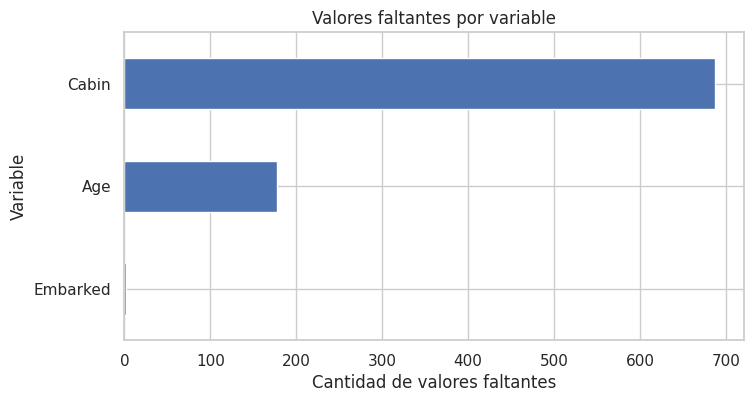

In [209]:
faltantes["Valores faltantes"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(8, 4)
)

plt.title("Valores faltantes por variable")
plt.xlabel("Cantidad de valores faltantes")
plt.ylabel("Variable")

plt.show()

### Observación

El análisis de valores faltantes muestra que `Cabin` es la variable con mayor cantidad de datos ausentes, con 687 registros faltantes, lo que representa aproximadamente el 77,1% del dataset.

La variable `Age` presenta 177 valores faltantes, equivalentes aproximadamente al 19,9% de los registros, mientras que `Embarked` solamente presenta 2 valores faltantes (0,2%).

Debido a la elevada proporción de valores ausentes en `Cabin`, se evaluará si esta variable aporta suficiente información como para conservarla en el modelo. En el caso de `Age`, se conservará la variable y se realizará una imputación de los valores faltantes. Los pocos valores faltantes de `Embarked` también serán tratados durante la etapa de limpieza.

## 6. Detección de registros duplicados

Se verifica la existencia de registros duplicados para evitar que un mismo pasajero aparezca más de una vez en el dataset.

In [210]:
df.duplicated().sum()

np.int64(0)

In [211]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


## 7. Análisis de correlaciones

Se analiza la relación entre las principales variables numéricas del dataset y la variable objetivo `Survived`.

Para este análisis se excluye `PassengerId`, ya que se trata de un identificador y no representa una característica del pasajero. Las variables categóricas se analizarán posteriormente luego de realizar las transformaciones correspondientes.

In [212]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

correlacion = df[variables_numericas].corr()

correlacion

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


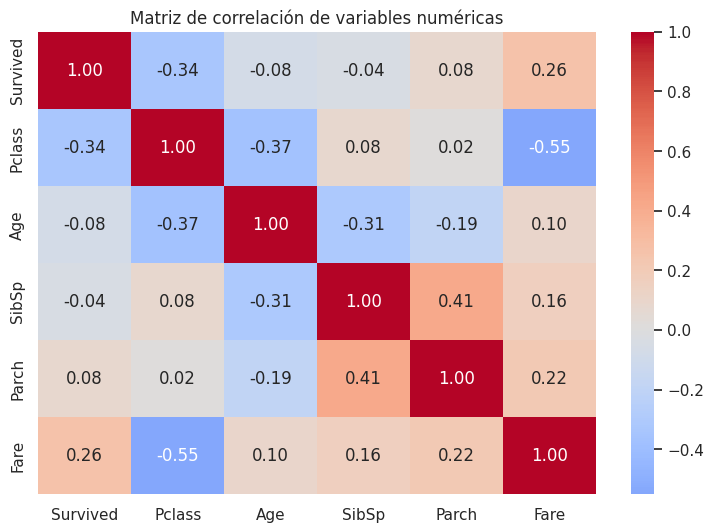

In [213]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")

plt.show()

In [214]:
correlacion["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
SibSp,-0.035322
Age,-0.077221
Pclass,-0.338481


### Observación

La matriz de correlación muestra diferencias en la relación de las variables numéricas con `Survived`.

La variable `Pclass` presenta la mayor correlación en valor absoluto con la supervivencia (-0,338), lo que indica una relación negativa: a medida que aumenta el número de clase, disminuye la proporción de supervivencia.

`Fare` presenta una correlación positiva de 0,257, mientras que `Parch` presenta una relación positiva muy débil (0,082). Por otro lado, `Age` (-0,077) y `SibSp` (-0,035) presentan relaciones lineales muy débiles con la variable objetivo.

Estos resultados permiten identificar inicialmente a `Pclass` y `Fare` como variables numéricas potencialmente relevantes. Sin embargo, la correlación por sí sola no determina la utilidad de una variable para un modelo de Machine Learning, por lo que las variables se evaluarán también teniendo en cuenta su significado y el análisis exploratorio realizado anteriormente.

## 8. Selección de variables

A partir del análisis exploratorio realizado, se seleccionan las variables que serán consideradas para la etapa posterior de modelado.

Se decide excluir `PassengerId` porque funciona únicamente como identificador del pasajero y no aporta información relevante sobre sus características.

También se excluyen `Name` y `Ticket`, ya que son variables de texto con una gran cantidad de valores diferentes y no serán utilizadas en esta primera versión del modelo.

La variable `Cabin` presenta aproximadamente un 77,1% de valores faltantes, por lo que se decide excluirla para evitar una imputación masiva de información que podría introducir ruido.

Se conservarán `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare` y `Embarked`, ya que presentan información potencialmente útil para explicar la supervivencia de los pasajeros.

La variable `Survived` se mantendrá como variable objetivo.

In [215]:
df_modelo = df.copy()

columnas_seleccionadas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "Survived"
]

df_modelo = df_modelo[columnas_seleccionadas]

df_modelo.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [216]:
df_modelo.shape

(891, 8)

## 9. División del dataset

Antes de realizar las transformaciones que dependen de los datos, se divide el dataset en variables predictoras (`X`) y variable objetivo (`y`).

Posteriormente se separarán los datos en un conjunto de entrenamiento y otro de prueba. Esta separación permite realizar las transformaciones utilizando únicamente la información disponible en el conjunto de entrenamiento y evaluar posteriormente el comportamiento del modelo sobre datos que no fueron utilizados durante su preparación.

In [217]:
X = df_modelo.drop("Survived", axis=1)
y = df_modelo["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (712, 7)
Tamaño de X_test: (179, 7)
Tamaño de y_train: (712,)
Tamaño de y_test: (179,)


### Tratamiento de valores faltantes

Los valores faltantes de `Age` serán reemplazados utilizando la mediana calculada sobre el conjunto de entrenamiento. Se elige la mediana porque es menos sensible a valores extremos que la media.

Para `Embarked`, al tratarse de una variable categórica con solamente dos valores faltantes, se utilizará la categoría más frecuente del conjunto de entrenamiento.

In [218]:
imputador_age = SimpleImputer(strategy="median")

X_train[["Age"]] = imputador_age.fit_transform(X_train[["Age"]])
X_test[["Age"]] = imputador_age.transform(X_test[["Age"]])

In [219]:
imputador_embarked = SimpleImputer(strategy="most_frequent")

X_train[["Embarked"]] = imputador_embarked.fit_transform(
    X_train[["Embarked"]]
)

X_test[["Embarked"]] = imputador_embarked.transform(
    X_test[["Embarked"]]
)

In [220]:
print("Valores faltantes en X_train:")
print(X_train.isnull().sum())

print("\nValores faltantes en X_test:")
print(X_test.isnull().sum())

Valores faltantes en X_train:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Valores faltantes en X_test:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [221]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [222]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


## 10. Transformación de variables categóricas

Las variables `Sex` y `Embarked` son categóricas y deben transformarse a una representación numérica para poder ser utilizadas posteriormente por los algoritmos de Machine Learning.

Se utilizará One-Hot Encoding, que crea una nueva variable binaria para cada categoría. De esta manera, las categorías no se interpretan como valores con un orden numérico artificial.

In [223]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)

columnas_categoricas = ["Sex", "Embarked"]

X_train_cat = encoder.fit_transform(X_train[columnas_categoricas])
X_test_cat = encoder.transform(X_test[columnas_categoricas])

In [224]:
encoder.get_feature_names_out(columnas_categoricas)

array(['Sex_male', 'Embarked_Q', 'Embarked_S'], dtype=object)

## 11. Escalado de variables numéricas

Las variables numéricas presentan diferentes escalas. Por ejemplo, `Pclass` toma valores entre 1 y 3, mientras que `Fare` puede alcanzar valores superiores a 500.

Debido a estas diferencias de escala, se aplicará `StandardScaler` a las variables numéricas. El escalado permitirá que las variables tengan una escala comparable y será especialmente importante para algoritmos sensibles a las distancias, como KNN.

El escalador será ajustado únicamente utilizando los datos de entrenamiento y posteriormente se aplicará al conjunto de prueba.

In [225]:
columnas_numericas = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[columnas_numericas])
X_test_num = scaler.transform(X_test[columnas_numericas])

In [226]:
X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

print("Dimensiones de X_train_final:", X_train_final.shape)
print("Dimensiones de X_test_final:", X_test_final.shape)

Dimensiones de X_train_final: (712, 8)
Dimensiones de X_test_final: (179, 8)


### Observación

Luego de aplicar las transformaciones, el conjunto de datos cuenta con 8 variables predictoras: cinco variables numéricas escaladas (`Pclass`, `Age`, `SibSp`, `Parch` y `Fare`) y tres variables binarias obtenidas mediante One-Hot Encoding (`Sex_male`, `Embarked_Q` y `Embarked_S`).

El conjunto de entrenamiento contiene 712 registros y el conjunto de prueba 179 registros. Los datos quedan preparados para ser utilizados en la etapa posterior de modelado.

## 12. Conclusiones de la Pre-Entrega

Durante esta primera etapa del proyecto se realizó el proceso de exploración y preparación del dataset Titanic para un futuro problema de clasificación.

El análisis exploratorio permitió identificar diferencias importantes en la supervivencia según variables como `Sex` y `Pclass`, así como detectar valores faltantes en `Age`, `Cabin` y `Embarked`. También se analizaron posibles valores atípicos en `Fare` y las correlaciones entre las principales variables numéricas.

A partir de este análisis se decidió excluir `PassengerId`, `Name`, `Ticket` y `Cabin`, mientras que se conservaron `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare` y `Embarked` por su posible utilidad para predecir la supervivencia.

Los valores faltantes de `Age` fueron tratados mediante imputación con la mediana y los de `Embarked` mediante la categoría más frecuente. Las variables categóricas fueron transformadas mediante One-Hot Encoding y las variables numéricas fueron estandarizadas.

Finalmente, el dataset fue dividido en conjuntos de entrenamiento y prueba, quedando preparado para la siguiente etapa del proyecto, en la cual se podrán entrenar y comparar diferentes modelos de clasificación.

En esta Pre-Entrega no se realizó entrenamiento ni evaluación de modelos, ya que dichas actividades corresponden a la etapa final del proyecto.